In [83]:
from experiments import einsum_QAOA, mps_QAOA
import numpy as np
import matplotlib.pyplot as plt
import tqdm 

# Сравнение точности выходных состояний QAOA при различных значениях max_bond для einsum и mps симуляторов

Тут мы фиксируем число слоев!

In [84]:
#число кубитов
n = 15
p = 21
r_values = [i for i in range(1, 21)]

In [85]:
Fid = np.zeros(len(r_values), dtype=float)
times = np.zeros(len(r_values), dtype=float)
ein_vector, t_ein = einsum_QAOA(n, p)
print("Time for einsum:", t_ein)
for idx, r in enumerate(tqdm.tqdm(r_values)):
    mps_vector, t_mps = mps_QAOA(num_qubits=n, p=p, max_bond=r)
    Fid[idx] = np.abs(np.dot(ein_vector.conj(), mps_vector))**2
    times[idx] = t_mps

print("Time for mps", np.mean(times), '+-', np.std(times))

print("t_ein/t_mps", t_ein/np.mean(times))

Time for einsum: 0.22043609619140625


100%|██████████| 20/20 [00:01<00:00, 18.94it/s]

Time for mps 0.05258297920227051 +- 0.030946383974469954
t_ein/t_mps 4.192156844964158


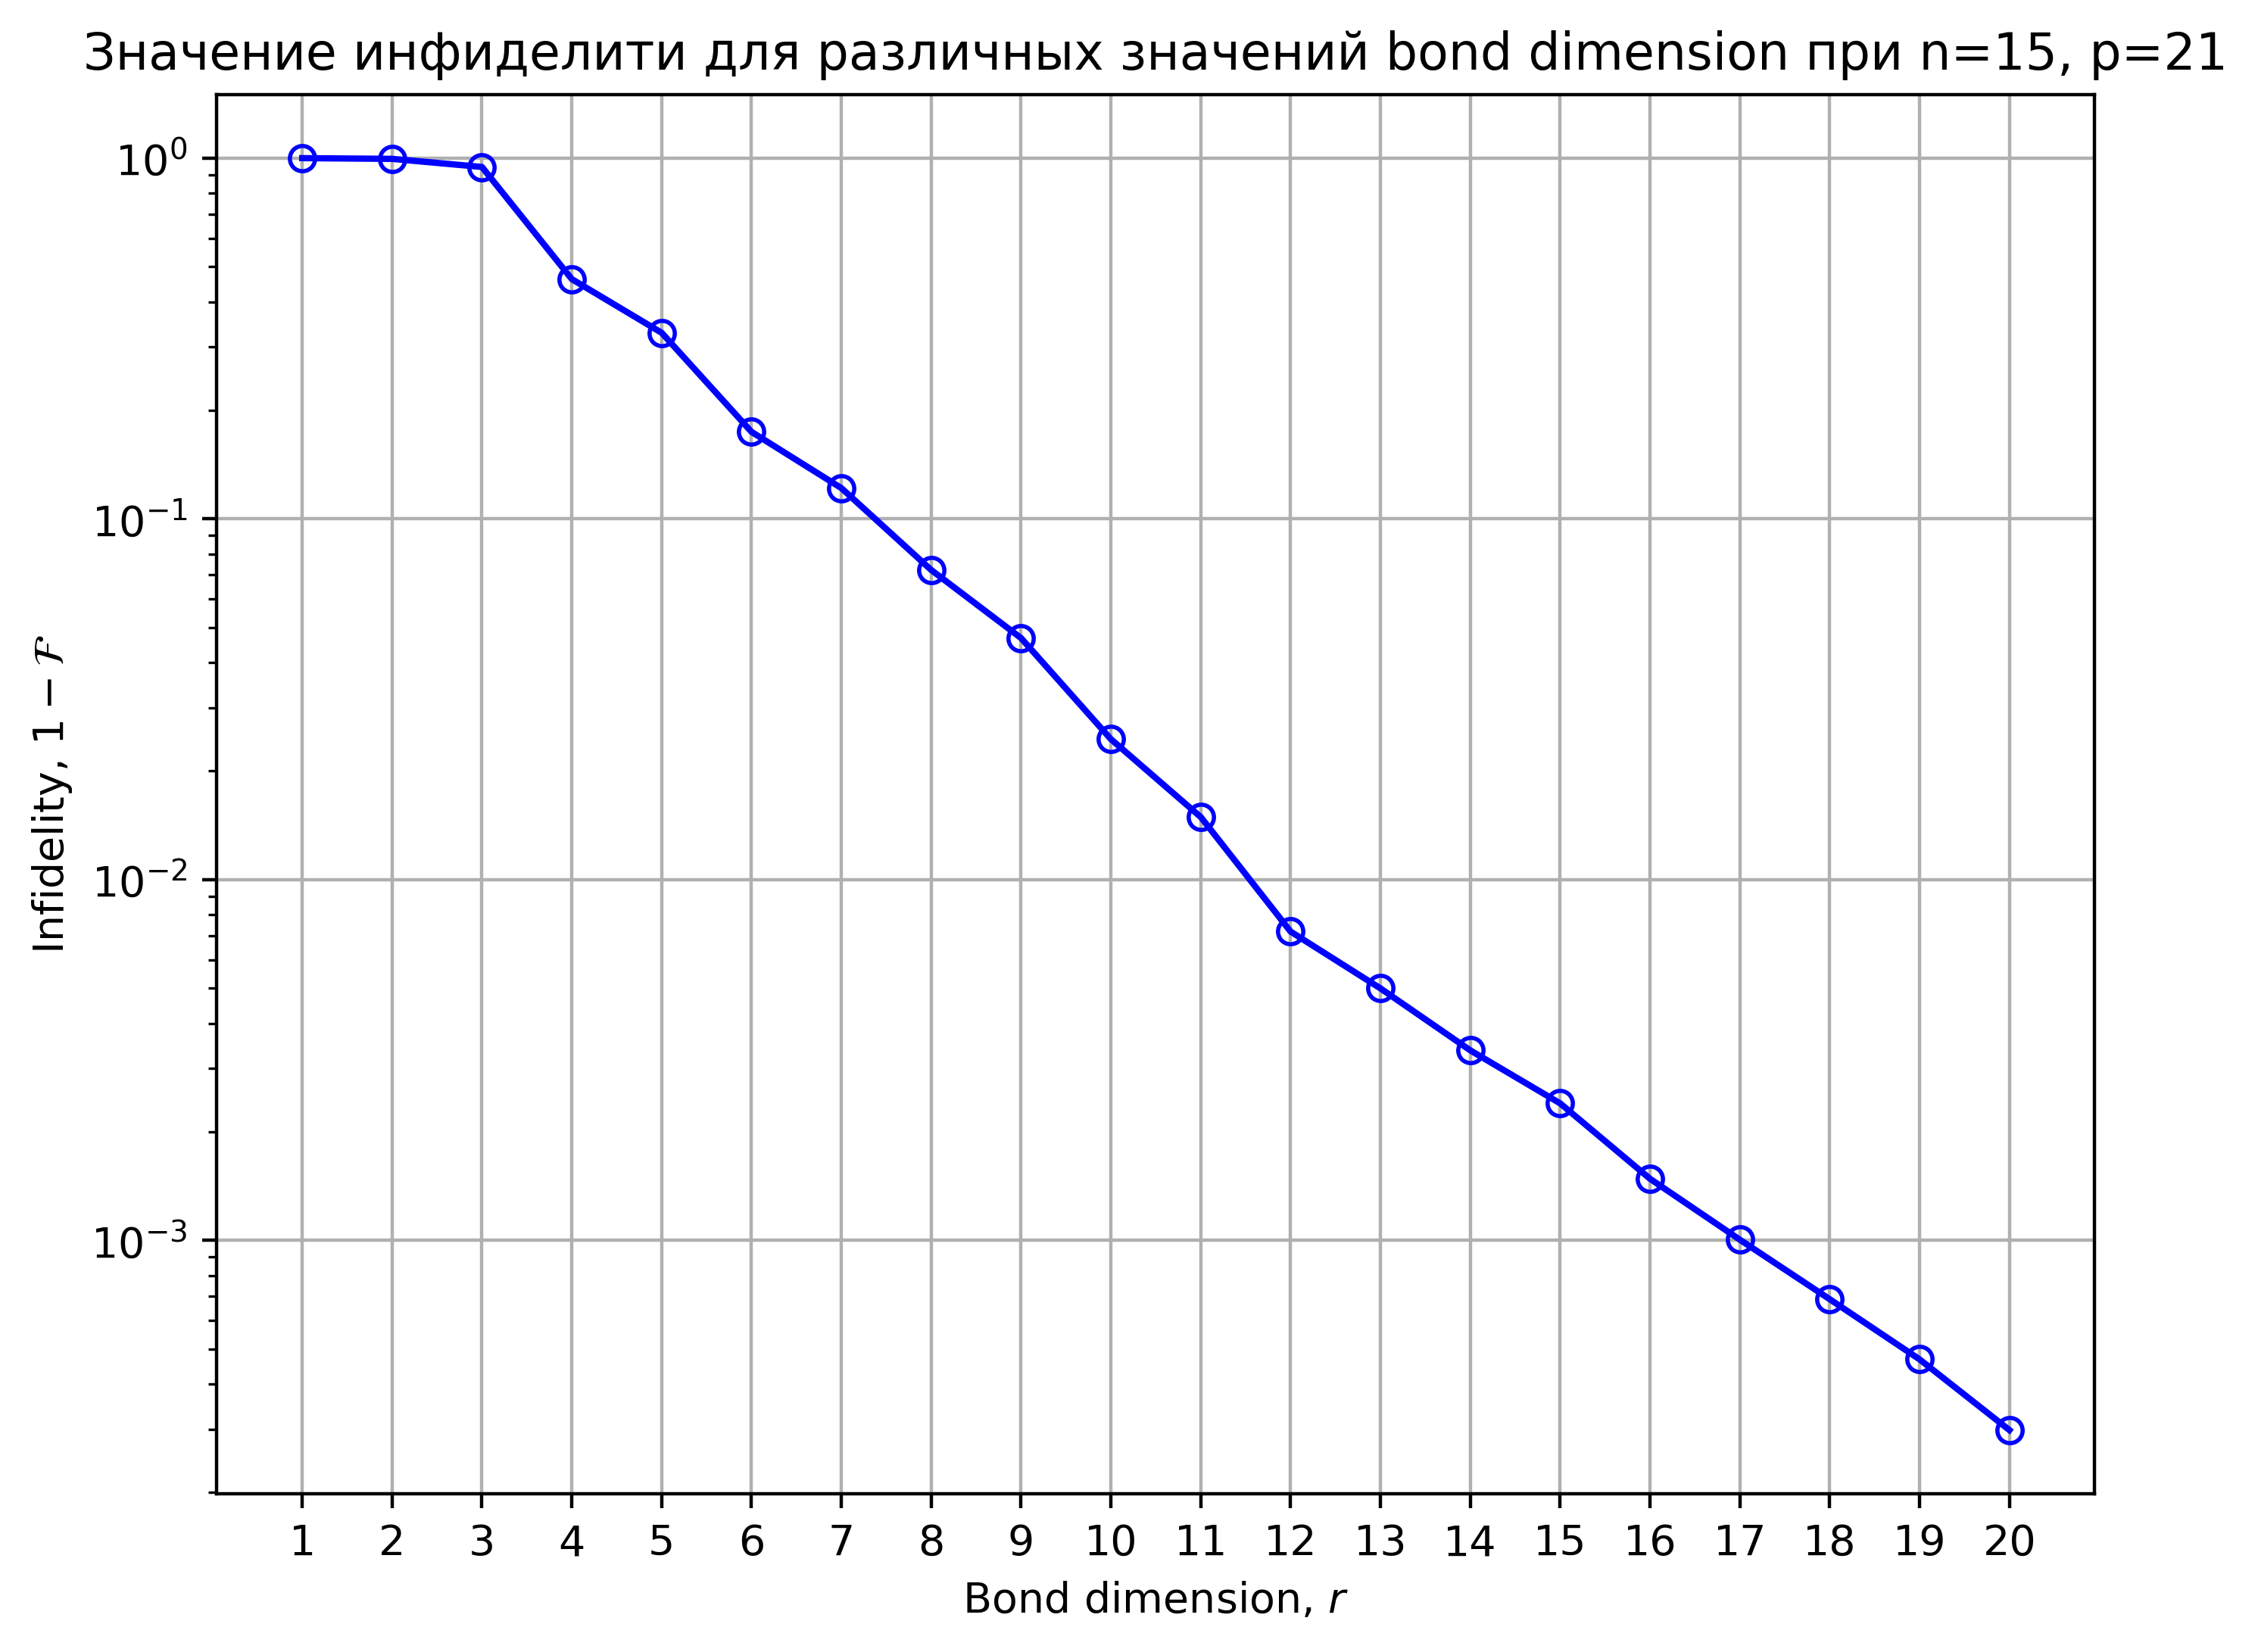

In [86]:
plt.figure(figsize=(8, 6), dpi=400)
plt.plot(r_values, 1 - Fid, marker='o', markeredgecolor='blue', markerfacecolor='none', linestyle='-', color='blue')
plt.title(f'Значение инфиделити для различных значений bond dimension при n={n}, p={p}')
plt.xlabel(r'Bond dimension, $r$')
plt.ylabel(r'Infidelity, $1 - \mathcal{F}$')
plt.grid()
plt.yscale('log')
plt.xticks(r_values)
plt.show()

# Сравнение точности получаемых состояний QAOA при различном числе слоев p для фиксированного bond_dimension

In [87]:
p_values = [i for i in range(1, 51)]
r = 5

In [88]:
Fid = np.zeros(len(p_values), dtype=float)
times_mps = np.zeros(len(p_values), dtype=float)
times_ein = np.zeros(len(p_values), dtype=float)

for idx, p in enumerate(tqdm.tqdm(p_values)):
    ein_vector, t_ein = einsum_QAOA(n, p)
    mps_vector, t_mps = mps_QAOA(num_qubits=n, p=p, max_bond=r)
    Fid[idx] = np.abs(np.dot(ein_vector.conj(), mps_vector))**2
    times_mps[idx] = t_mps
    times_ein[idx] = t_ein

print("Time for mps", np.mean(times), '+-', np.std(times))
print("Time for einsum:", np.mean(times_ein), '+-', np.std(times_ein))

print("t_ein/t_mps", np.mean(times_ein)/np.mean(times_mps))

100%|██████████| 50/50 [00:14<00:00,  3.41it/s]

Time for mps 0.05258297920227051 +- 0.030946383974469954
Time for einsum: 0.260282506942749 +- 0.13148179160548357
t_ein/t_mps 8.077665768016969


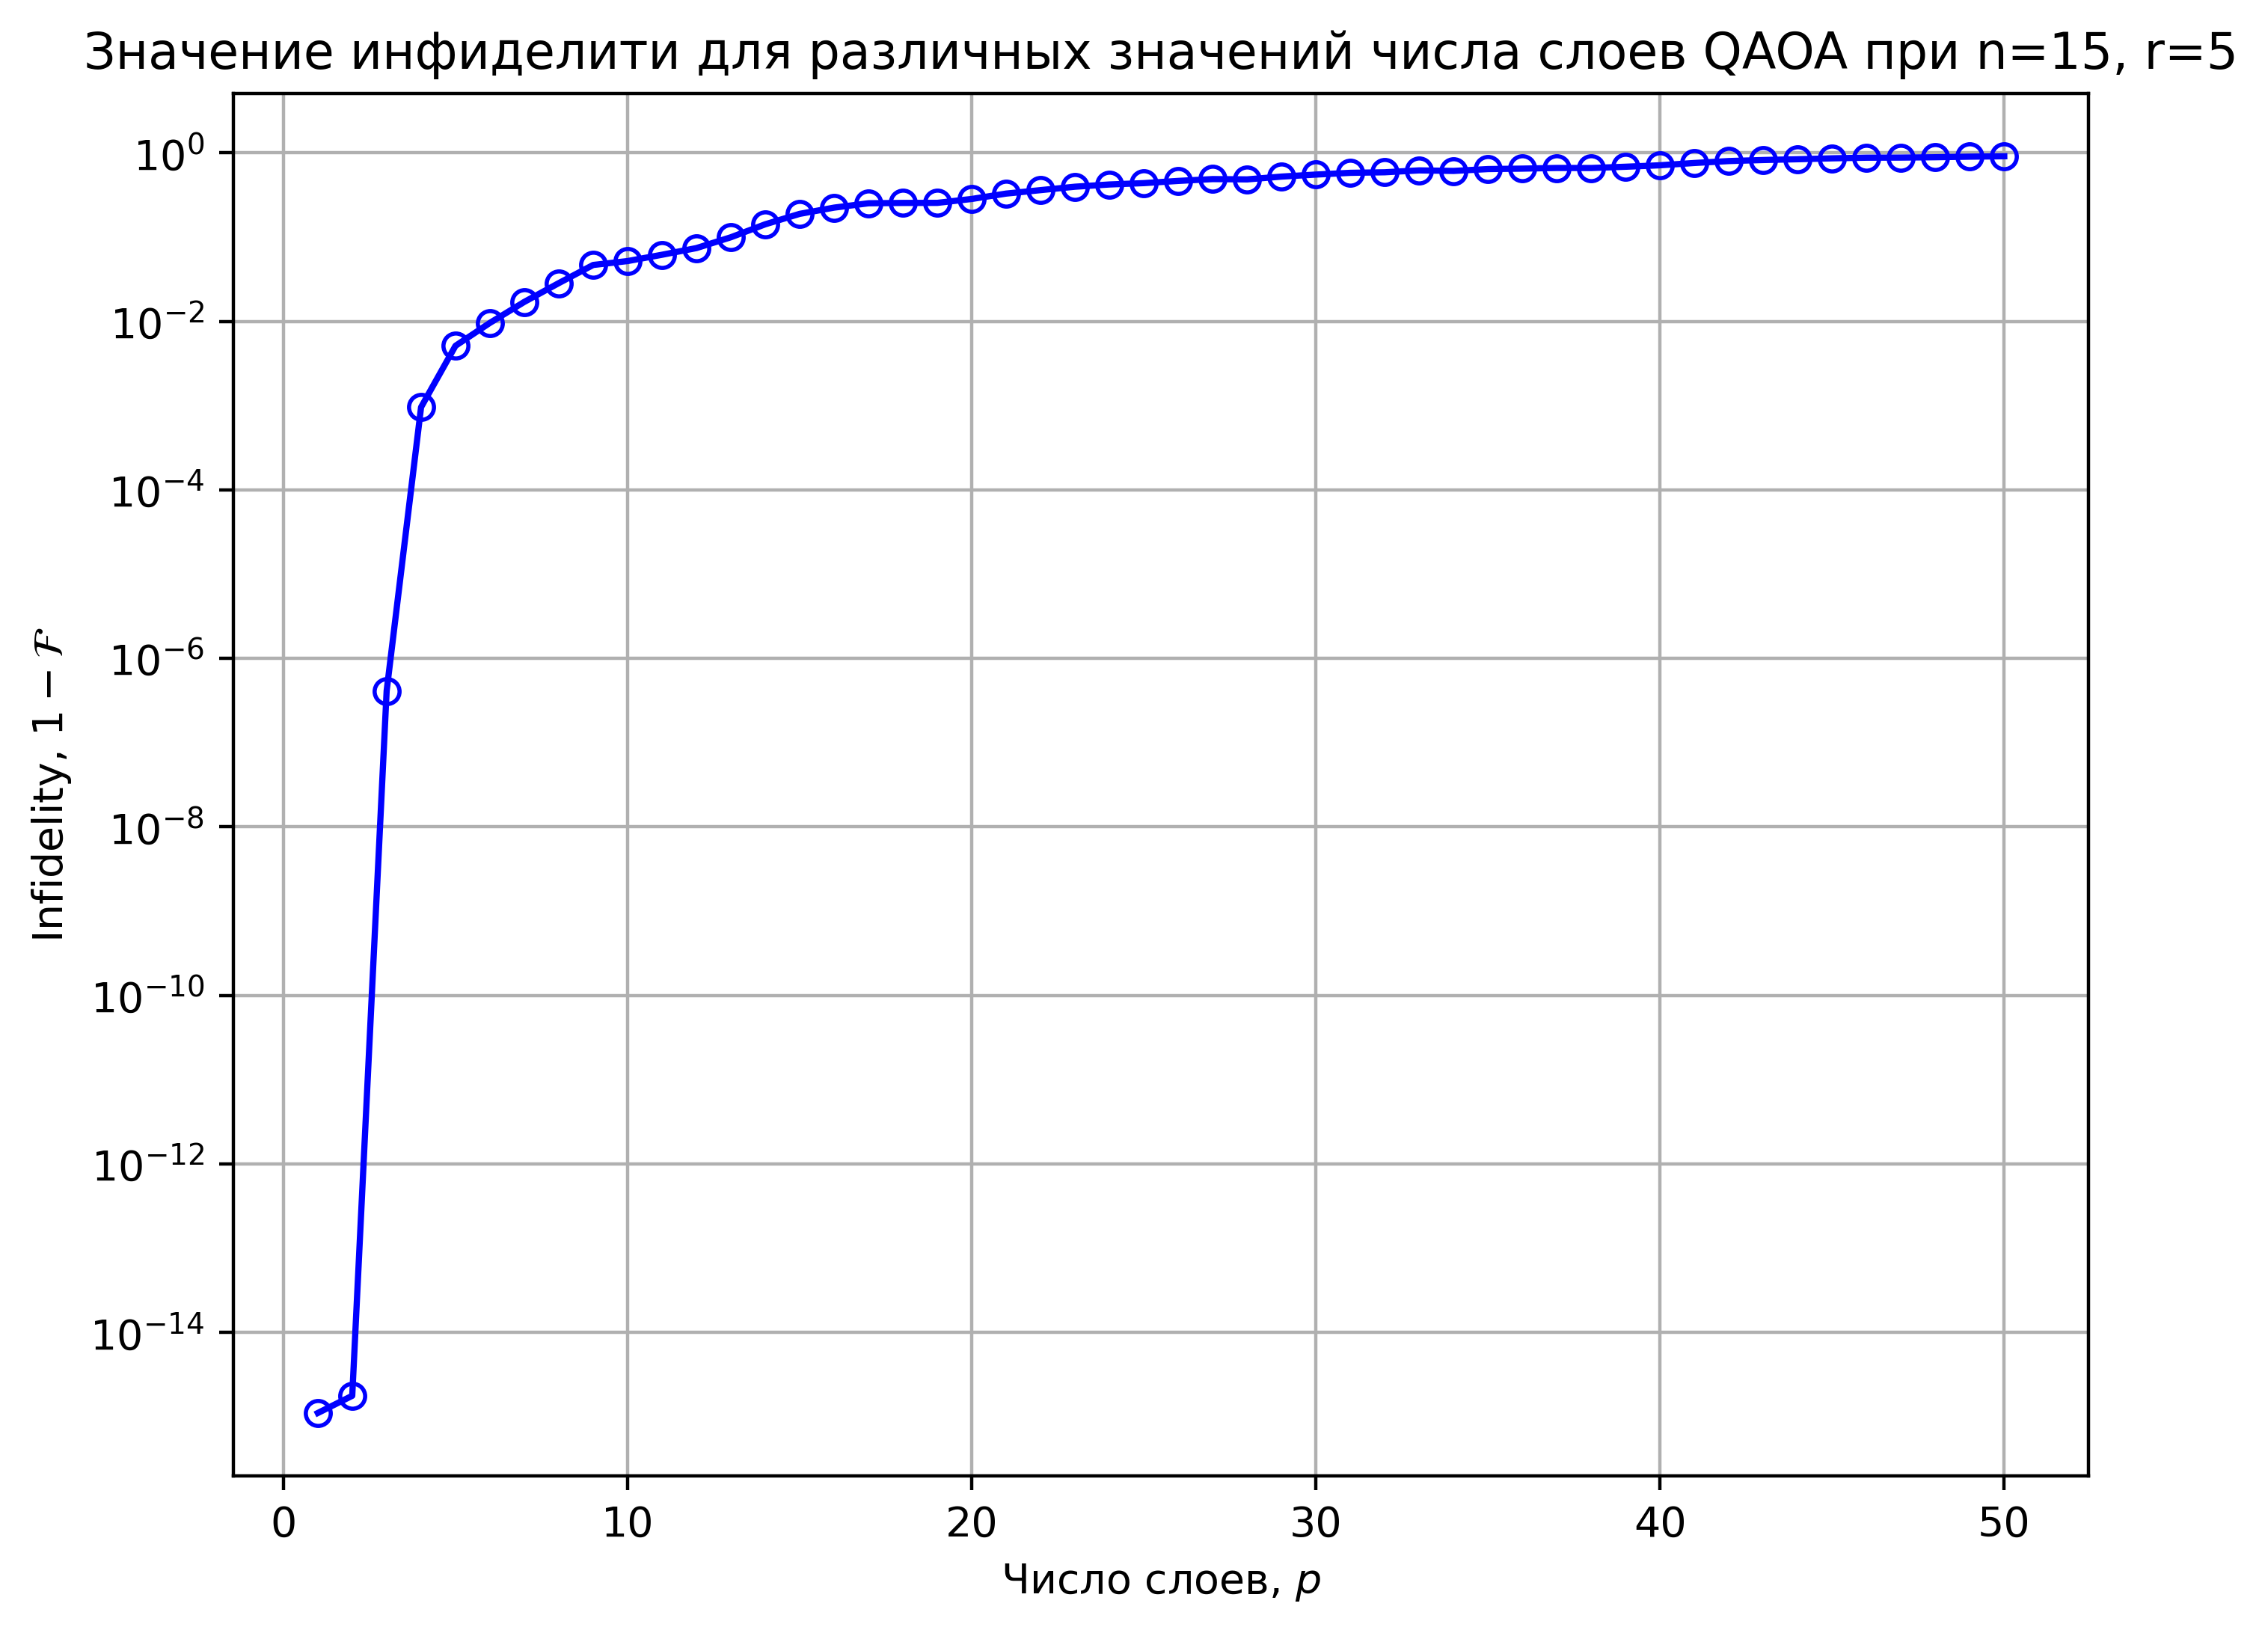

In [89]:
plt.figure(figsize=(8, 6), dpi=400)
plt.plot(p_values, 1 - Fid, marker='o', markeredgecolor='blue', markerfacecolor='none', linestyle='-', color='blue')
plt.title(f'Значение инфиделити для различных значений числа слоев QAOA при n={n}, r={r}')
plt.xlabel(r'Число слоев, $p$')
plt.ylabel(r'Infidelity, $1 - \mathcal{F}$')
plt.grid()
plt.yscale('log')
plt.show()

# Получаем поверхность по обеим осям

In [90]:
p_values = [i for i in range(1, 51)]
r_values = p_values

In [91]:
Fid_matrix = np.zeros((len(p_values), len(r_values)), dtype=float)
times_mps_matrix = np.zeros((len(p_values), len(r_values)), dtype=float)

times_ein_array = np.zeros(len(p_values), dtype=float)

for p_idx, p in enumerate(tqdm.tqdm(p_values, desc="Слои (p)")):
    
    ein_vector, t_ein = einsum_QAOA(n, p)
    times_ein_array[p_idx] = t_ein
    
    for r_idx, r in enumerate(r_values):
        
        mps_vector, t_mps = mps_QAOA(num_qubits=n, p=p, max_bond=r)

        Fid_matrix[p_idx, r_idx] = np.abs(np.dot(ein_vector.conj(), mps_vector))**2
        
        times_mps_matrix[p_idx, r_idx] = t_mps


Infidelity_matrix = 1.0 - Fid_matrix


Слои (p): 100%|██████████| 50/50 [13:13<00:00, 15.88s/it]


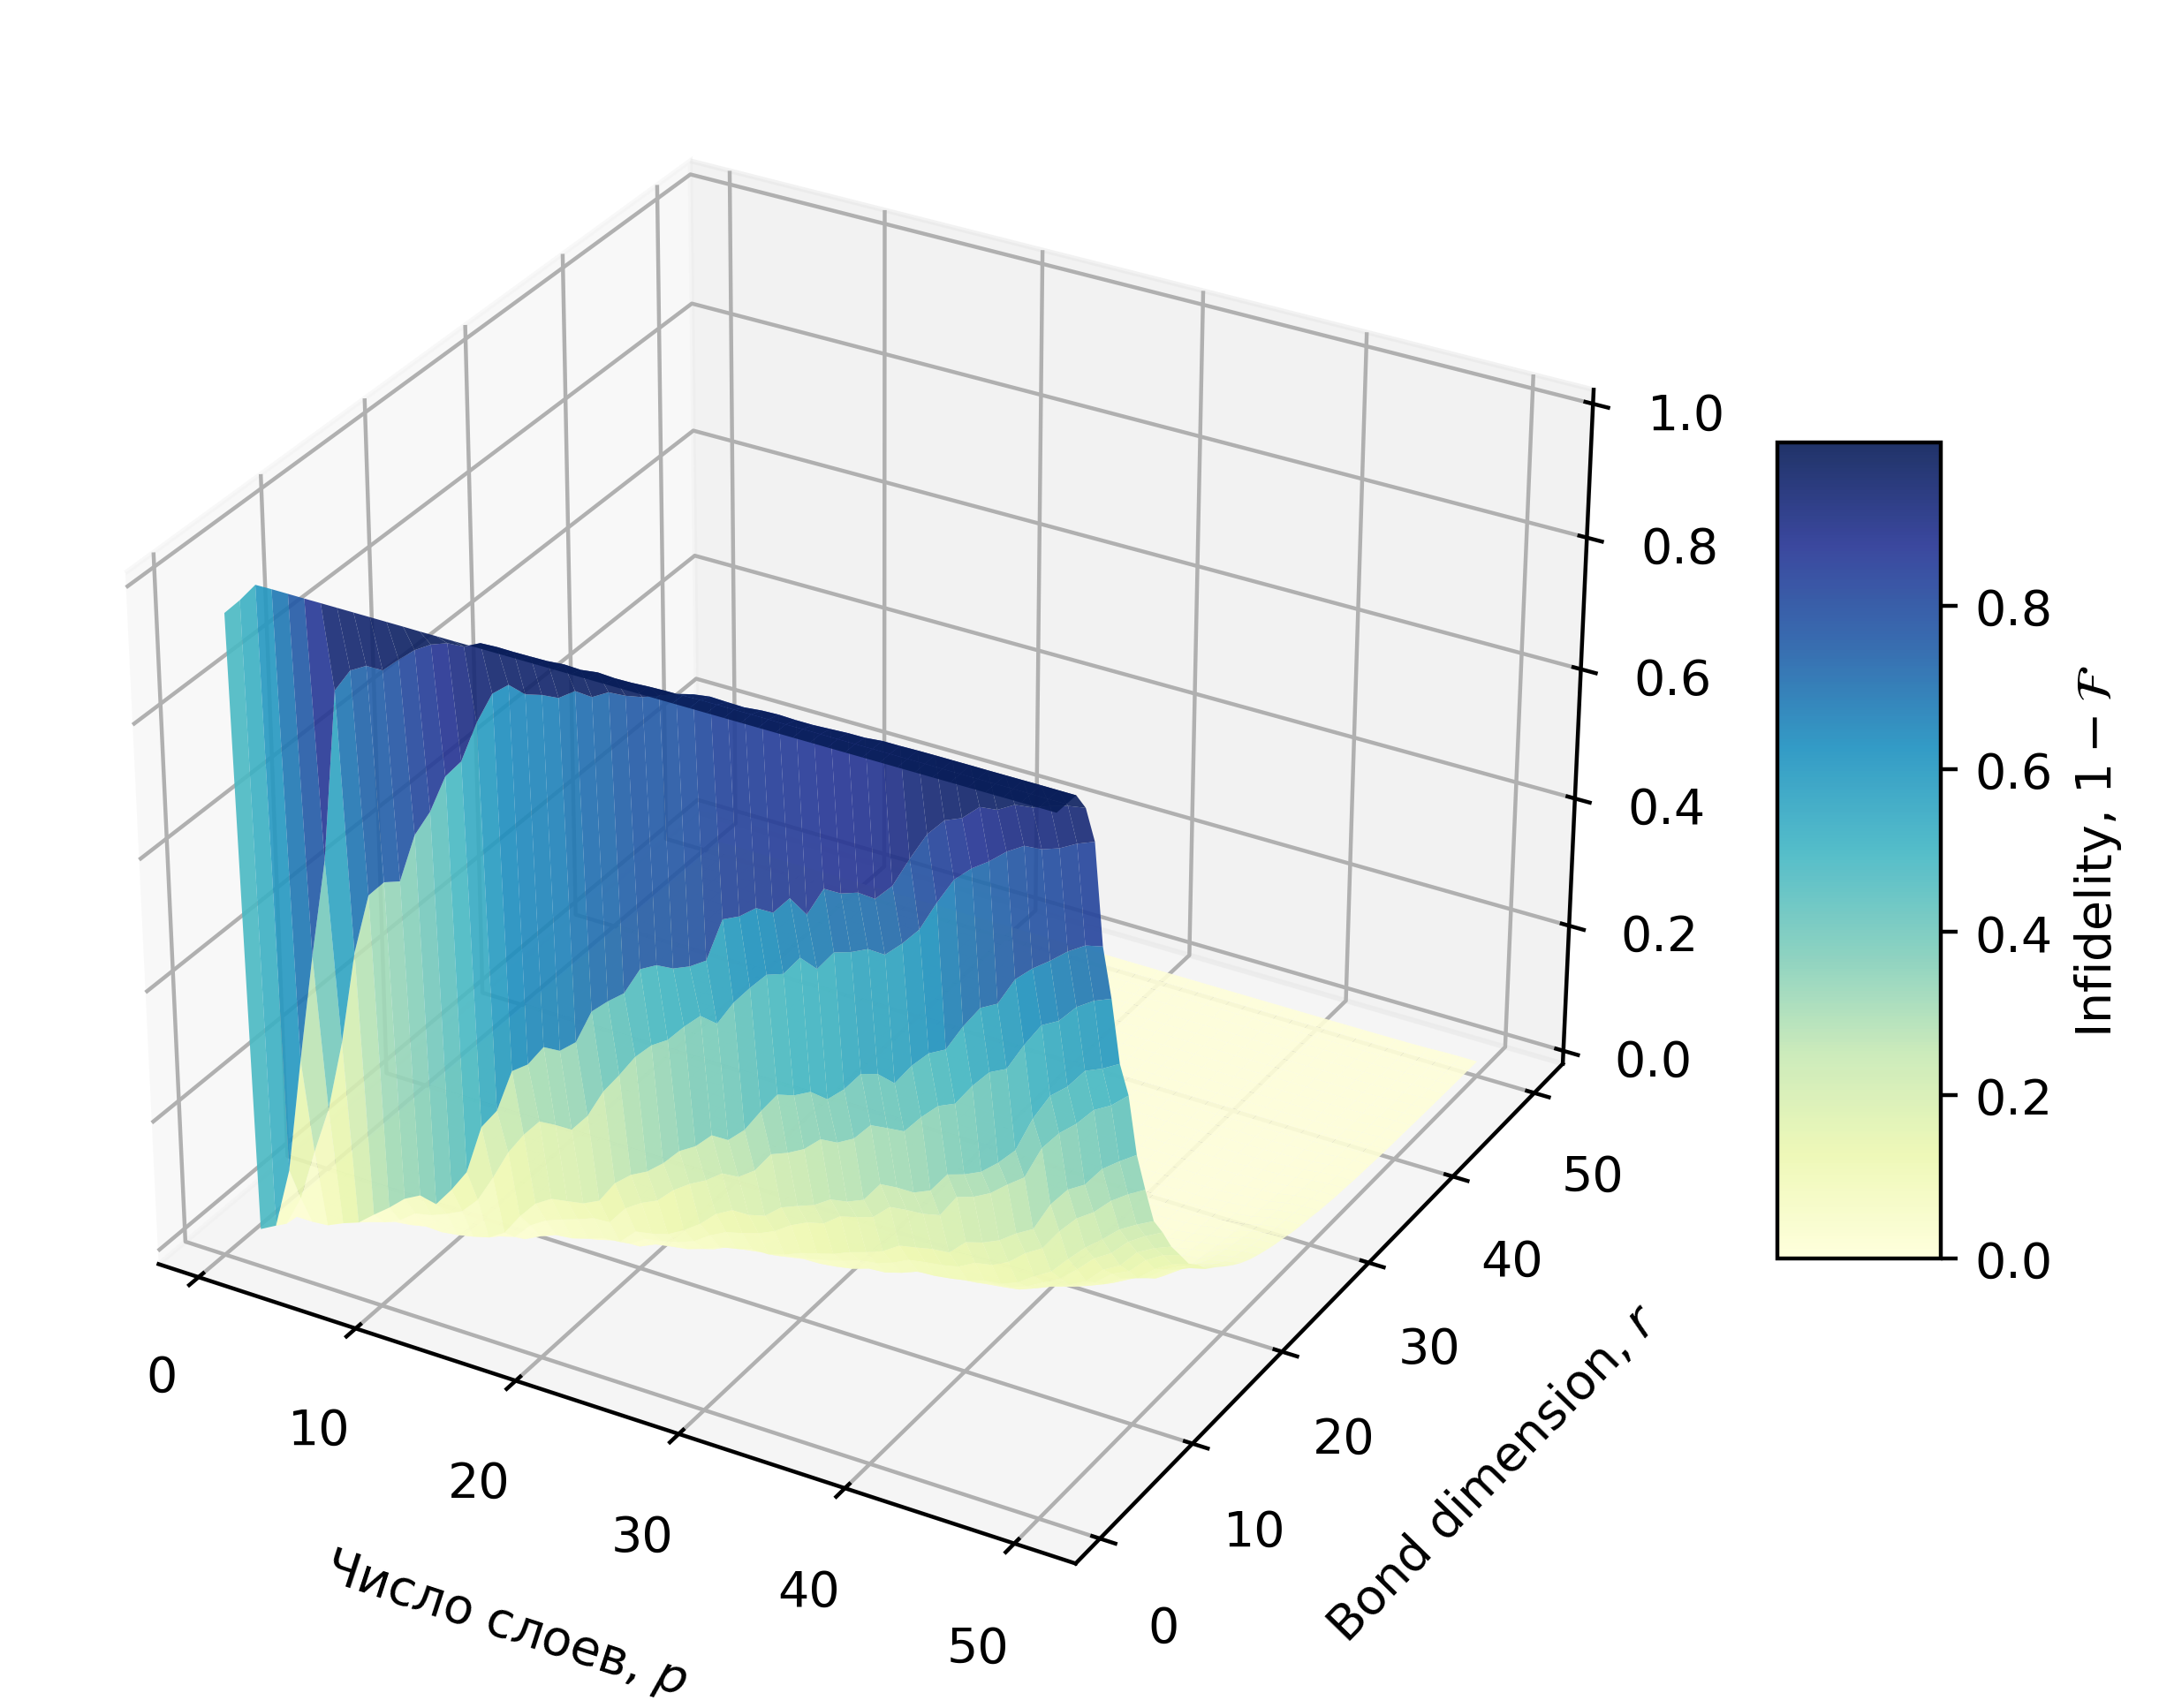

In [92]:
fig = plt.figure(figsize=(8, 6), dpi=400)
ax = fig.add_subplot(111, projection='3d')

cmap = plt.cm.YlGnBu

# Создаем сетку
P, R = np.meshgrid(p_values, r_values)

# Транспонируем матрицу Z, так как meshgrid возвращает оси в порядке (Y, X)
Z = Infidelity_matrix.T 

# Строим график (можно добавить логарифм, если значения очень маленькие)
surf = ax.plot_surface(P, R, Z, cmap=cmap, edgecolor='none', alpha=0.9)

ax.set_xlabel(r'Число слоев, $p$', labelpad=10)
ax.set_ylabel(r'Bond dimension, $r$', labelpad=10)
ax.set_zlabel(r'Infidelity, $1 - \mathcal{F}$', labelpad=10)
fig.colorbar(surf, shrink=0.5, aspect=5, label=r'Infidelity, $1 - \mathcal{F}$')

plt.show()

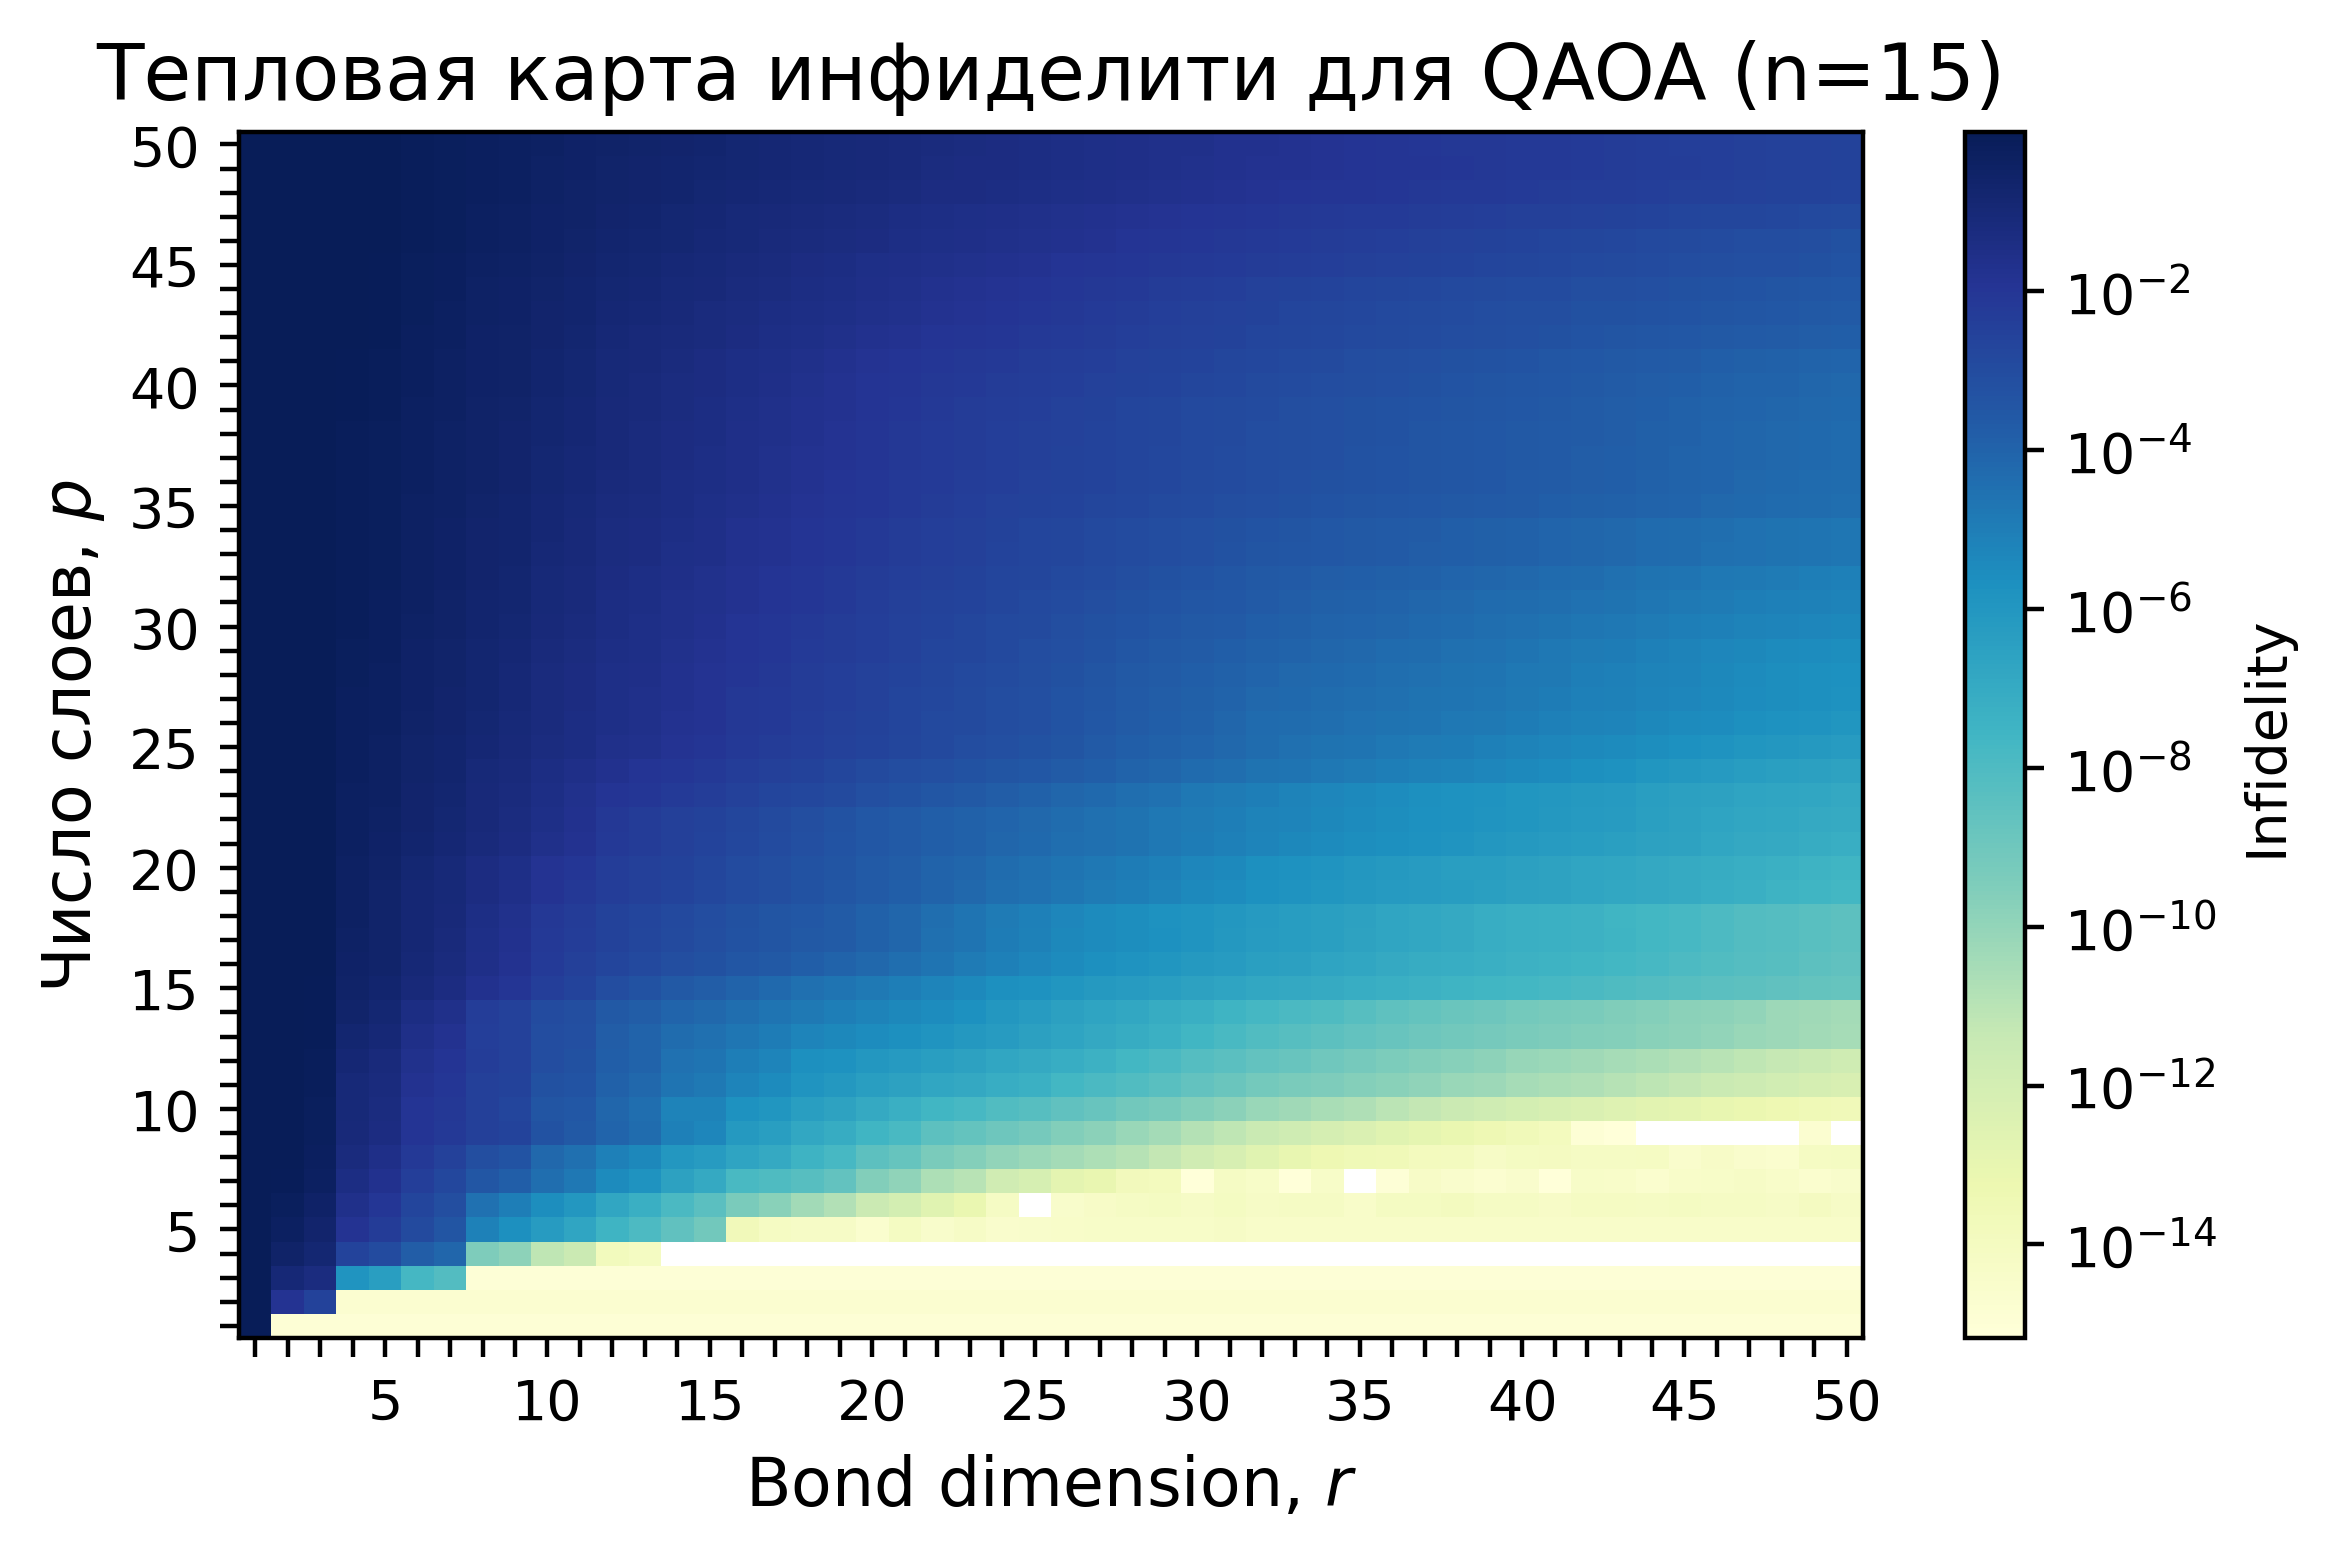

In [99]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(6, 4), dpi=400)
im = ax.imshow(Infidelity_matrix, cmap=cmap, origin='lower', aspect='auto',
               extent=[r_values[0]-0.5, r_values[-1]+0.5, p_values[0]-0.5, p_values[-1]+0.5],
               norm=LogNorm())

# Настраиваем оси
ax.set_xlabel(r'Bond dimension, $r$', fontsize=12)
ax.set_ylabel(r'Число слоев, $p$', fontsize=12)
ax.set_title(f'Тепловая карта инфиделити для QAOA (n={n})', fontsize=14)


ax.set_xticks(r_values)
ax.set_yticks(p_values)
ax.set_yticklabels([i if i % 5 == 0 else '' for i in p_values]) 
ax.set_xticklabels([i if i % 5 == 0 else '' for i in r_values])
cbar = fig.colorbar(im, ax=ax, label='Infidelity')

plt.tight_layout()
plt.show()

Сравнение времени вычислений. Тут я фиксирую max_bond до 20.

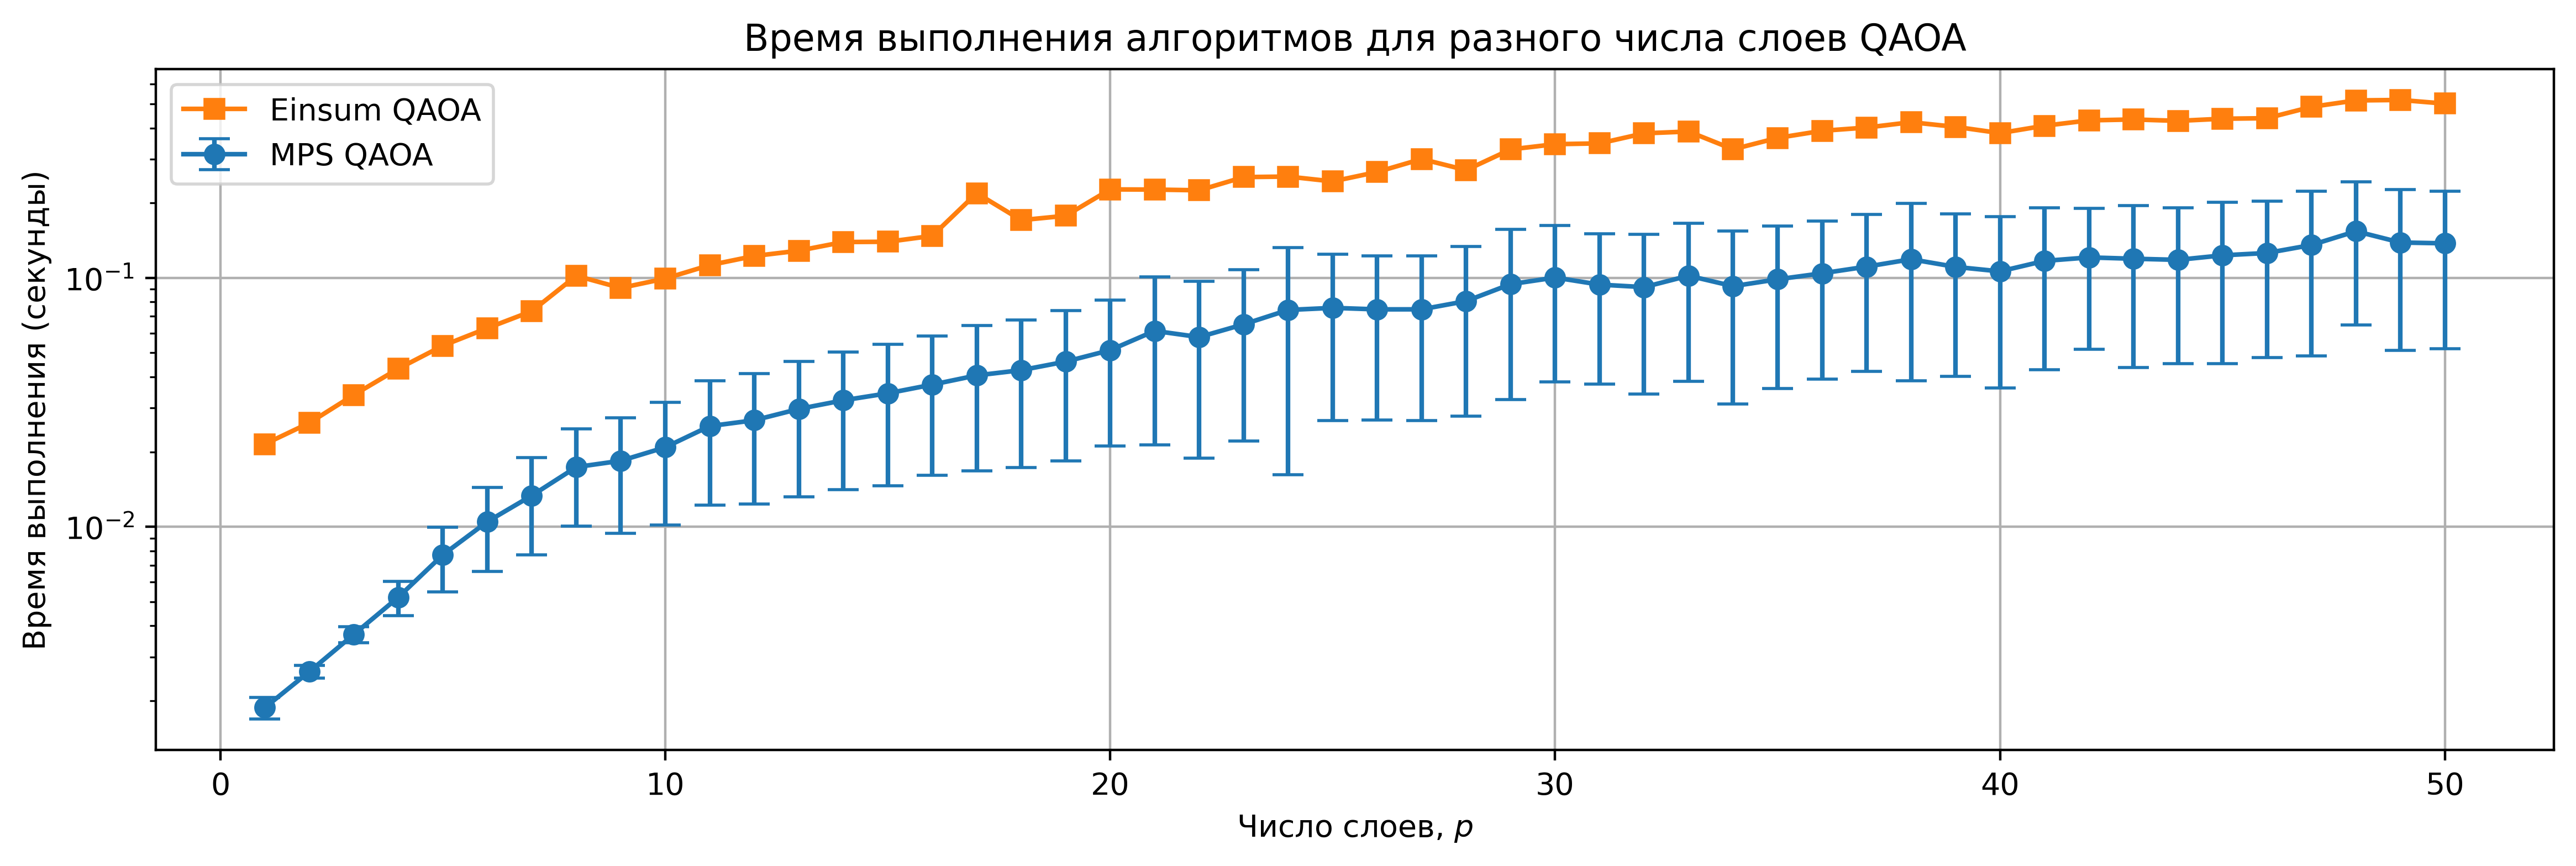

In [102]:
times_mps_mean = np.mean(times_mps_matrix[:, :20], axis=1)
times_mps_std = np.std(times_mps_matrix[:, :20], axis=1)

plt.figure(figsize=(14, 4), dpi=400)
plt.errorbar(p_values, times_mps_mean, yerr=times_mps_std, fmt='o-', label='MPS QAOA', capsize=5)
plt.plot(p_values, times_ein_array, 's-', label='Einsum QAOA')
plt.title(f'Время выполнения алгоритмов для разного числа слоев QAOA')
plt.xlabel(r'Число слоев, $p$')
plt.ylabel(r'Время выполнения (секунды)')
plt.grid()
plt.legend()
plt.yscale('log')
plt.show()
